In [1]:
#!/usr/bin/env python
# coding: utf-8
import os
from os import system
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from tm.core.prior import GlobalEquilibriumHarmonicPrior, UnitNormalPrior
from tm.core.backbone import ConvBackbone
from tm.core.diffusion_model import DiffusionTrainer, SteeredDiffusionSampler
from tm.core.diffusion_process import VPDiffusion
from tm.architectures.unet_2d_mid_attn import Unet2D
from tm.core.loader import Loader
import seaborn as sns

import os
if not os.path.exists('plots/'):
    os.mkdir('plots')


In [2]:
highP= np.load('../data/p8.npy')
lowP = np.load('../data/p1.npy')

lowP  = lowP.reshape(lowP.shape[0],lowP.shape[1],16,16)
highP  = highP.reshape(highP.shape[0],highP.shape[1],16,16)

p_data_coordinate = np.concatenate((lowP, highP, ), axis=0)
p_data_coordinate.shape

(20000, 2, 16, 16)

In [3]:
# Initialize pressure values
pressure = np.array([-2, 2])
pressure_list = np.ones(p_data_coordinate.shape[0]*2)
temperature_list = 25* np.ones(p_data_coordinate.shape[0]*2)

for i in range(2):
    pressure_list[p_data_coordinate.shape[0]*i:p_data_coordinate.shape[0]*(i+1)] = pressure[i]

# Add two additional channels for temperature and pressure
expanded_data = np.zeros((p_data_coordinate.shape[0],4, p_data_coordinate.shape[2], p_data_coordinate.shape[3]))

# Copy original data to the expanded array
expanded_data[:, :2, :, :] = p_data_coordinate
# print(expanded_data.shape)

# Set the 4th channel to 400 (temperature)
expanded_data[:, 2, :, :] = 25

# # Set the 5th channel to the pressure values
# expanded_data[:, 13, :, :] = p_data_coordinate[:, 12, :, :]

data_sh = int(expanded_data.shape[0]/2)

expanded_data[:data_sh,3,:,:] = pressure[0]
expanded_data[data_sh:,3,:,:] = pressure[1]

# Create trajectory dictionary
trajectoryP = {'coordinate': [], 'state_variables': [],'state_variables_P': []}
trajectoryP['coordinate'] = expanded_data[:, :4, :, :]
trajectoryP['state_variables_P'] = pressure_list
trajectoryP['state_variables'] = temperature_list



In [4]:

train_loader = Loader(data=trajectoryP['coordinate'], pressures =trajectoryP['state_variables_P'][:,None] , temperatures=trajectoryP['state_variables'][:,None],control_dims=(2,4))#, **TMLoader_kwargs)
prior = GlobalEquilibriumHarmonicPrior(shape=train_loader.data.shape, channels_info={"coordinate": [0,1], "fluctuation": [2], "mean": [3]})
model = Unet2D(dim=16, dim_mults=(1, 2, 4), resnet_block_groups=8, channels=4)






In [6]:

backbone = ConvBackbone(model=model,
                        data_shape=train_loader.data_dim,
                        target_shape=16,
                        num_dims=4,
                        lr=1e-3,
                        eval_mode="train",
                        self_condition=True)

diffusion = VPDiffusion(num_diffusion_timesteps=100)

trainer = DiffusionTrainer(diffusion,
                           backbone,
                           train_loader,
                           prior,
                           model_dir="thermomaps-root/models", # save models every epoch
                           pred_type="x0", # set to "noise" or "x0"
#                            test_loader=test_loader # optional
                           )

trainer.train(40, loss_type="smooth_l1", batch_size=128)





epoch: 0 | train loss: 0.055
epoch: 1 | train loss: 0.019
epoch: 2 | train loss: 0.026
epoch: 3 | train loss: 0.016
epoch: 4 | train loss: 0.017
epoch: 5 | train loss: 0.022
epoch: 6 | train loss: 0.014
epoch: 7 | train loss: 0.015
epoch: 8 | train loss: 0.023
epoch: 9 | train loss: 0.014
epoch: 10 | train loss: 0.013
epoch: 11 | train loss: 0.012
epoch: 12 | train loss: 0.012
epoch: 13 | train loss: 0.013
epoch: 14 | train loss: 0.012
epoch: 15 | train loss: 0.012
epoch: 16 | train loss: 0.011
epoch: 17 | train loss: 0.012
epoch: 18 | train loss: 0.011
epoch: 19 | train loss: 0.013
epoch: 20 | train loss: 0.012
epoch: 21 | train loss: 0.014
epoch: 22 | train loss: 0.019
epoch: 23 | train loss: 0.016
epoch: 24 | train loss: 0.011
epoch: 25 | train loss: 0.014
epoch: 26 | train loss: 0.017
epoch: 27 | train loss: 0.016
epoch: 28 | train loss: 0.015
epoch: 29 | train loss: 0.011
epoch: 30 | train loss: 0.010
epoch: 31 | train loss: 0.010
epoch: 32 | train loss: 0.010
epoch: 33 | train lo

In [7]:
# *********************************************************************************
#                               Sampling
# *********************************************************************************
sampler = SteeredDiffusionSampler(diffusion,
                                  backbone,
                                  train_loader,
                                  prior,
                                  pred_type='x0', # must be the same as in DiffusionTrainer
                                  )


num_samp = 50

In [18]:
highP_ref= np.load('../data/p8.npy')
lowP_ref = np.load('../data/p1.npy')


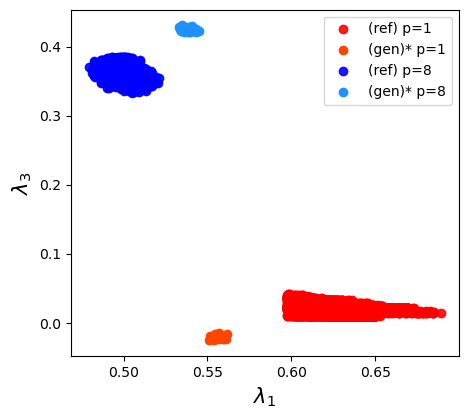

In [19]:
plt.figure(figsize=(5,4.5))

# p=1 (ref) and (gen) share the same color
plt.scatter(lowP_ref[:,0,:].mean(axis=1), lowP_ref[:,1,:].mean(axis=1), 
            label='(ref) p=1', alpha=0.9, color='red')
plt.scatter(low_gen_data[:,0,:].mean(axis=1), low_gen_data[:,1,:].mean(axis=1), 
            label='(gen)* p=1', color='orangered')

# p=8 (ref) and (gen) share the same color
plt.scatter(highP_ref[:,0,:].mean(axis=1), highP_ref[:,1,:].mean(axis=1), 
            label='(ref) p=8', alpha=0.9, color='blue')
plt.scatter(high_gen_data[:,0,:].mean(axis=1), high_gen_data[:,1,:].mean(axis=1), 
            label='(gen)* p=8', color='dodgerblue')


plt.xlabel(r'$\lambda_1$',fontsize= 15)
plt.ylabel(r'$\lambda_3$',fontsize= 15)
plt.legend()


/tmp/ipykernel_2878731/1780419516.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = cm.get_cmap('coolwarm', len(pressure_range))


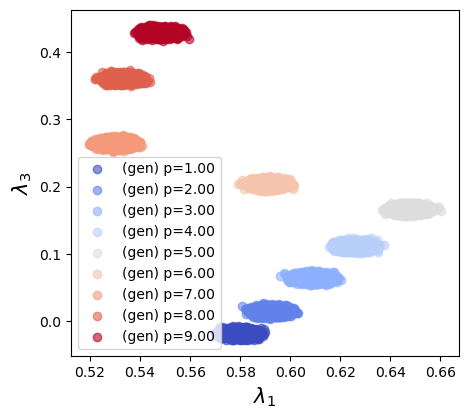

In [104]:
import matplotlib.cm as cm

plt.figure(figsize=(5, 4.5))
pressure_range = [-2,-1.5, -1, -0.5,0,0.5, 1,1.5, 2]
pressure_actual = np.linspace(1,8,len(pressure_range))#[1, 2.75, 4.5, 7.25, 9]
num_samp1 = 5000

# Define a color map (e.g., 'Blues' for blue gradient)
color_map = cm.get_cmap('coolwarm', len(pressure_range))
gen_samples_pressure= [] 
for i, p in enumerate(pressure_range):
    gen_samples = sampler.sample_loop(num_samples=num_samp1, batch_size=32, pressure=p, temperature=25)
    gen_samples = gen_samples.numpy()
    gen_samples = gen_samples[:, :2, :, :].reshape(gen_samples.shape[0], 2, 256)
    gen_samples_pressure.append(gen_samples)
    # Set color based on pressure index
    color = color_map(i / len(pressure_range))
    plt.scatter(gen_samples[:, 0, :].mean(axis=1), gen_samples[:, 1, :].mean(axis=1),
                label=f'(gen) p={pressure_actual[i]:.2f}', alpha=0.6, color=color)

plt.legend()
plt.xlabel(r'$\lambda_1$', fontsize=15)
plt.ylabel(r'$\lambda_3$', fontsize=15)
plt.show()


In [105]:
gen_samples_pressure = np.array(gen_samples_pressure)
np.save('../data/gen_samples_pressure_list_new.npy',gen_samples_pressure)

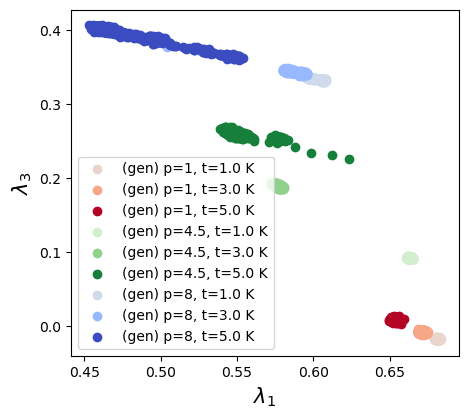

In [22]:
# Define temperature ranges
temperature_range = [1, 2.5, 5]
temperature_range = [i*25 for i in temperature_range]
temperature_actual = np.linspace(1,5,3)#[#1, 2.5, 5]
num_samp1 = 1000

# Define color maps for blue and orange gradients, starting from a slightly darker level
blue_cmap = cm.coolwarm(np.linspace(0.45, 0, 256))  # Start at 0.3 for darker blue shades
orange_cmap = cm.coolwarm(np.linspace(0.55, 1, 256))  # Start at 0.3 for darker orange shades
green_cmap = cm.Greens(np.linspace(0.2,.8, 256))  # Start at 0.3 for darker orange shades

# Normalize temperature for color mapping
norm = plt.Normalize(min(temperature_range), max(temperature_range))

gen_samples_lam1_temp = []
gen_samples_lam2_temp = []
gen_samples_lam3_temp = []

plt.figure(figsize=(5,4.5))
for i, t in enumerate(temperature_range):
    gen_samples_lam1 = sampler.sample_loop(num_samples=num_samp1, batch_size=32, pressure=-1.5, temperature=t)
    gen_samples_lam1 = gen_samples_lam1.numpy()[:, :2, :, :].reshape(gen_samples_lam1.shape[0], 2, 256)
    color_orange = orange_cmap[int(norm(t) * 255)]
    gen_samples_lam1_temp.append(gen_samples_lam1)
    # Plot gen_samples_lam1 with the orange gradient for p=1
    plt.scatter(gen_samples_lam1[:, 0, :].mean(axis=1), gen_samples_lam1[:, 1, :].mean(axis=1), 
                label=f'(gen) p=1, t={temperature_actual[i]:.1f} K', color=color_orange)

plt.legend()

for i, t in enumerate(temperature_range):
    # Sampling
    gen_samples_lam3 = sampler.sample_loop(num_samples=num_samp1, batch_size=32, pressure=1.5, temperature=t)
    gen_samples_lam3 = gen_samples_lam3.numpy()[:, :2, :, :].reshape(gen_samples_lam3.shape[0], 2, 256)
    color_blue = blue_cmap[int(norm(t) * 255)]
    gen_samples_lam3_temp.append(gen_samples_lam3)
    # Plot gen_samples_lam3 with the blue gradient for p=8
    plt.scatter(gen_samples_lam3[:, 0, :].mean(axis=1), gen_samples_lam3[:, 1, :].mean(axis=1), 
                label=f'(gen) p=8, t={temperature_actual[i]:.1f} K', color=color_blue)

for i, t in enumerate(temperature_range):
    # Sampling
    gen_samples_lam2 = sampler.sample_loop(num_samples=num_samp1, batch_size=32, pressure=0, temperature=t)
    gen_samples_lam2 = gen_samples_lam2.numpy()[:, :2, :, :].reshape(gen_samples_lam2.shape[0], 2, 256)
    color_green = green_cmap[int(norm(t) * 255)]
    gen_samples_lam2_temp.append(gen_samples_lam2)
    # Plot gen_samples_lam3 with the blue gradient for p=8
    plt.scatter(gen_samples_lam2[:, 0, :].mean(axis=1), gen_samples_lam2[:, 1, :].mean(axis=1), 
                label=f'(gen) p=4.5, t={temperature_actual[i]:.1f} K', color=color_green)

# Final plot adjustments
plt.xlabel(r'$\lambda_1$', fontsize=15)
plt.ylabel(r'$\lambda_3$', fontsize=15)
plt.legend()

gen_samples_lam1_temp = np.array(gen_samples_lam1_temp)
gen_samples_lam2_temp = np.array(gen_samples_lam2_temp)
gen_samples_lam3_temp = np.array(gen_samples_lam3_temp)

np.save('../data/gen_samples_lam1_temp.npy',gen_samples_lam1_temp)
np.save('../data/gen_samples_lam2_temp.npy',gen_samples_lam2_temp)
np.save('../data/gen_samples_lam3_temp.npy',gen_samples_lam3_temp)
